<a href="https://colab.research.google.com/github/caladriusllc-code/caladrius-ml-learn/blob/learning-branch/SolveExoKeras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [25]:
n_samples = 1000

# Avoir des data identiques
np.random.seed(42)

# Générer des données pour la classe 0 avec du bruit
x0_noisy = np.random.rand(n_samples, 2) * 5 + np.random.normal(0, 1.5, (n_samples, 2))
y0_noisy = np.zeros(n_samples)

# Générer des données pour la classe 1 avec du bruit
x1_noisy = np.random.rand(n_samples, 2) * 5 + np.array([5, 5]) + np.random.normal(0, 1.5, (n_samples, 2))
y1_noisy = np.ones(n_samples)

# Combiner les données bruitées
X_noisy = np.vstack((x0_noisy, x1_noisy))
y_noisy = np.hstack((y0_noisy, y1_noisy))

In [26]:
# The plot showing the decision boundary and the dataset points has already been generated.
# Please refer to the output of the cell above this one to see the plot.

In [27]:
# On va normaliser ici
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_noisy)

In [28]:
from sklearn.model_selection import train_test_split

# Split data into training+validation set (80%) and test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_scaled, y_noisy, test_size=0.2, random_state=42, stratify=y_noisy
)

# Split training+validation set into training set (80%) and validation set (20%)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

In [29]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu", input_shape=(2,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(2, activation="softmax")  # 2 classes → softmax
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

In [31]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5000 - loss: 0.6707 - val_accuracy: 0.5000 - val_loss: 0.6679
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5305 - loss: 0.6625 - val_accuracy: 0.5312 - val_loss: 0.6600
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5781 - loss: 0.6540 - val_accuracy: 0.6062 - val_loss: 0.6515
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6578 - loss: 0.6449 - val_accuracy: 0.6719 - val_loss: 0.6424
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6867 - loss: 0.6352 - val_accuracy: 0.7375 - val_loss: 0.6325
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7523 - loss: 0.6247 - val_accuracy: 0.7844 - val_loss: 0.6219
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8031 - loss: 0.6133 - val_accuracy: 0.7937 - val_loss: 0.6103
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8195 - loss: 0.6013 - val_accuracy: 0.8156 - val_loss:

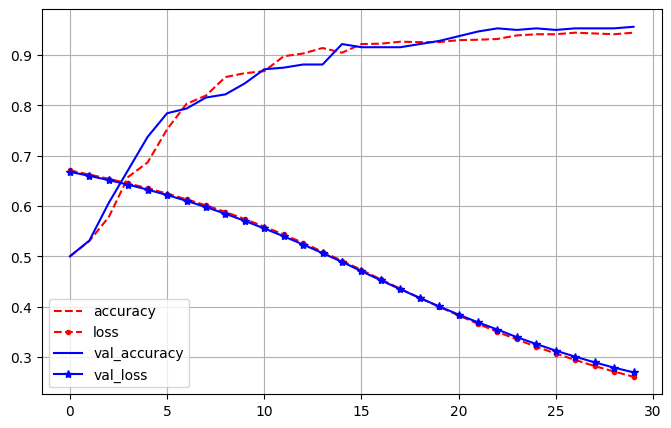

In [32]:
# Afficher les details de mon apprentissage
pd.DataFrame(history.history).plot(
    figsize=(8, 5),
    grid=True,
    style=['r--', 'r--.', 'b-', 'b-*']
    )
plt.show()

In [33]:
model.evaluate(X_test, y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9275 - loss: 0.2812  


[0.2812071144580841, 0.9275000095367432]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


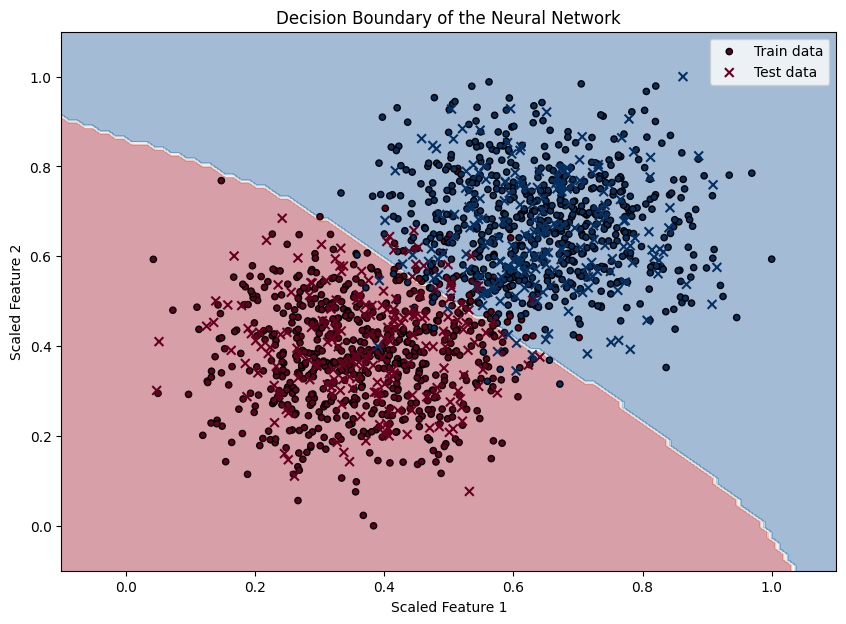

In [34]:
plt.figure(figsize=(10, 7))

# Définir les limites de la grille en fonction des données X_scaled
x_min, x_max = X_scaled[:, 0].min() - 0.1, X_scaled[:, 0].max() + 0.1
y_min, y_max = X_scaled[:, 1].min() - 0.1, X_scaled[:, 1].max() + 0.1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Faire des prédictions sur la grille
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)

# Tracer la frontière de décision
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdBu)

# Tracer les points d'entraînement
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20, edgecolor='k', cmap=plt.cm.RdBu, label='Train data')

# Tracer les points de test
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=40, marker='x', cmap=plt.cm.RdBu, label='Test data')

plt.title('Decision Boundary of the Neural Network')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.legend()
plt.show()